# 01 — EDA ASSISTments corrected collapsed

Notebook khởi động theo plan v3. Không train, không chọn tham số bằng test.
Nguồn: https://sites.google.com/site/assistmentsdata/home/2009-2010-assistment-data/skill-builder-data-2009-2010
CSV do người dùng cung cấp; tên/schema phù hợp bản corrected, chưa đối chiếu checksum bản tải chính thức.


In [1]:
from pathlib import Path
import hashlib, json, platform, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
ROOT = Path.cwd()
if not (ROOT / 'data/raw').exists():
    ROOT = ROOT.parent
assert (ROOT / 'data/raw').exists(), 'Run from project root or notebooks/'
RAW = ROOT / 'data/raw/skill_builder_data_corrected_collapsed.csv'
TABLES = ROOT / 'artifacts/tables'
PLOTS = ROOT / 'artifacts/plots'
SEED = 42
manifest = {'filename': RAW.name, 'bytes': RAW.stat().st_size,
            'sha256': hashlib.sha256(RAW.read_bytes()).hexdigest(),
            'encoding': 'cp1252', 'encoding_note': 'UTF-8 fails at byte 13450483; cp1252 strict roundtrip succeeds; historical encoding inferred',
            'python': platform.python_version(), 'pandas': pd.__version__,
            'source_status': 'user supplied; official download checksum not verified',
            'documentation_url': 'https://sites.google.com/site/assistmentsdata/home/2009-2010-assistment-data/skill-builder-data-2009-2010'}
(ROOT / 'data/raw/manifest.json').write_text(json.dumps(manifest, indent=2), encoding='utf-8')
print(json.dumps(manifest, indent=2))

{
  "filename": "skill_builder_data_corrected_collapsed.csv",
  "bytes": 64412812,
  "sha256": "162ef8d2d28bcbfea6591a282994062bd8d5eaa00636544292a0d268dca6e5da",
  "encoding": "cp1252",
  "encoding_note": "UTF-8 fails at byte 13450483; cp1252 strict roundtrip succeeds; historical encoding inferred",
  "python": "3.10.11",
  "pandas": "2.3.3",
  "source_status": "user supplied; official download checksum not verified",
  "documentation_url": "https://sites.google.com/site/assistmentsdata/home/2009-2010-assistment-data/skill-builder-data-2009-2010"
}


## 1. Schema và tính toàn vẹn toàn file
Không dùng thống kê nhãn test để chọn mô hình.

In [2]:
# Giữ ID dạng chuỗi, không suy diễn thành số thứ tự.
df = pd.read_csv(RAW, encoding='cp1252', dtype={'skill_id':'string','skill_name':'string','user_id':'string','problem_id':'string'}, low_memory=False)
required = {'order_id','user_id','problem_id','skill_id','skill_name','correct'}
assert required.issubset(df.columns), required - set(df.columns)
print('Shape:', df.shape)
display(pd.DataFrame({'dtype':df.dtypes.astype(str), 'missing':df.isna().sum(), 'missing_rate':df.isna().mean()}))
df.info()
schema = pd.DataFrame({'column':df.columns,'dtype':df.dtypes.astype(str).values,'missing':df.isna().sum().values})
schema.to_csv(TABLES / 'eda_schema.csv', index=False)

Shape: (346860, 31)


,dtype,missing,missing_rate
Unnamed: 0,int64,0,0.000000
order_id,int64,0,0.000000
assignment_id,int64,0,0.000000
user_id,string,0,0.000000
assistment_id,int64,0,0.000000
problem_id,string,0,0.000000
original,int64,0,0.000000
correct,int64,0,0.000000
attempt_count,int64,0,0.000000
ms_first_response,int64,0,0.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 346860 entries, 0 to 346859
Data columns (total 31 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Unnamed: 0            346860 non-null  int64  
 1   order_id              346860 non-null  int64  
 2   assignment_id         346860 non-null  int64  
 3   user_id               346860 non-null  string 
 4   assistment_id         346860 non-null  int64  
 5   problem_id            346860 non-null  string 
 6   original              346860 non-null  int64  
 7   correct               346860 non-null  int64  
 8   attempt_count         346860 non-null  int64  
 9   ms_first_response     346860 non-null  int64  
 10  tutor_mode            346860 non-null  object 
 11  answer_type           346860 non-null  object 
 12  sequence_id           346860 non-null  int64  
 13  student_class_id      346860 non-null  int64  
 14  position              346860 non-null  int64  
 15  

In [3]:
skill = df['skill_id'].str.strip()
missing_skill = skill.isna() | skill.eq('').fillna(False)
single = skill.str.fullmatch(r'\d+', na=False)
multi = skill.str.fullmatch(r'\d+(?:_\d+)+', na=False)
unrecognized = ~(missing_skill | single | multi)
index_cols = [c for c in df if c.startswith('Unnamed:')]
semantic_cols = [c for c in df if c not in index_cols]
audit = {
 'raw_rows':len(df), 'raw_students':df.user_id.nunique(),
 'raw_problems':df.problem_id.nunique(), 'missing_skill_rows':int(missing_skill.sum()),
 'rows_after_missing_skill_filter':int((~missing_skill).sum()),
 'single_skill_rows':int(single.sum()), 'multi_skill_rows':int(multi.sum()),
 'unrecognized_skill_rows':int(unrecognized.sum()),
 'single_skill_retained_rate':float(single.mean()),
 'invalid_target_rows':int((~df.correct.isin([0,1])).sum()),
 'missing_identity_rows':int(df[['user_id','problem_id','order_id']].isna().any(axis=1).sum()),
 'duplicate_semantic_rows':int(df.duplicated(semantic_cols).sum()),
 'duplicate_order_ids':int(df.order_id.duplicated().sum()),
 'duplicate_student_order_rows':int(df.duplicated(['user_id','order_id']).sum()),
 'repeated_student_problem_rows':int(df.duplicated(['user_id','problem_id']).sum())
}
print(json.dumps(audit, indent=2))
print('Multi-skill encodings:', skill[multi].drop_duplicates().head(15).tolist())
print('Unrecognized encodings:', skill[unrecognized].drop_duplicates().head(15).tolist())
assert audit['invalid_target_rows']==0
assert audit['missing_identity_rows']==0
assert audit['unrecognized_skill_rows']==0
assert audit['duplicate_student_order_rows']==0, 'Resolve interaction identity before sorting/modeling'
(TABLES / 'eda_audit.json').write_text(json.dumps(audit, indent=2), encoding='utf-8')

{
  "raw_rows": 346860,
  "raw_students": 4217,
  "raw_problems": 26688,
  "missing_skill_rows": 63755,
  "rows_after_missing_skill_filter": 283105,
  "single_skill_rows": 236068,
  "multi_skill_rows": 47037,
  "unrecognized_skill_rows": 0,
  "single_skill_retained_rate": 0.680585827134867,
  "invalid_target_rows": 0,
  "missing_identity_rows": 0,
  "duplicate_semantic_rows": 0,
  "duplicate_order_ids": 0,
  "duplicate_student_order_rows": 0,
  "repeated_student_problem_rows": 4779
}
Multi-skill encodings: ['1_13', '1_15', '2_37_70', '2_37_48_77', '2_48_79', '2_37_48', '2_70', '5_375', '5_102', '9_14', '9_12', '9_15', '9_13', '10_12', '10_13']
Unrecognized encodings: []


488

## 2. Subset dự kiến và split theo student
Lọc chỉ theo cấu trúc skill_id: giữ chuỗi số đơn; không tách multi-skill thành nhiều dòng.
Không tự động xóa repeated student-problem. Split seed 42, 70/15/15 theo số sinh viên.
Lưu manifest để các notebook sau dùng lại. Đây là split chuẩn bị; Gate A chưa khóa.


In [4]:
clean = df.loc[single].copy()
clean['skill_id'] = skill.loc[single]
clean['source_row'] = np.flatnonzero(single.to_numpy())
clean = clean.sort_values(['user_id','order_id'], kind='stable').reset_index(drop=True)
users = np.array(sorted(clean.user_id.unique()))
rng = np.random.default_rng(SEED)
rng.shuffle(users)
n_train = int(len(users)*0.70)
n_val = int(len(users)*0.15)
parts = {'train':users[:n_train], 'validation':users[n_train:n_train+n_val], 'test':users[n_train+n_val:]}
sets = {k:set(v) for k,v in parts.items()}
assert sets['train'].isdisjoint(sets['validation'])
assert sets['train'].isdisjoint(sets['test'])
assert sets['validation'].isdisjoint(sets['test'])
assert set.union(*sets.values()) == set(users)
manifest_split = {'seed':SEED, 'method':'numpy default_rng shuffled sorted cleaned user IDs; floor 70%, floor 15%, remainder',
                  'raw_sha256':manifest['sha256'], 'students':{k:v.tolist() for k,v in parts.items()}}
split_path = ROOT / 'data/processed/student_split.json'
if split_path.exists():
    assert json.loads(split_path.read_text(encoding='utf-8')) == manifest_split, 'Existing split differs; do not silently overwrite'
else:
    split_path.write_text(json.dumps(manifest_split,indent=2),encoding='utf-8')
train = clean[clean.user_id.isin(sets['train'])].copy()
print('Clean single-skill rows:',len(clean))
print('Split student counts:', {k:len(v) for k,v in parts.items()})
print('Detailed EDA below uses TRAIN only.')

Clean single-skill rows: 236068
Split student counts: {'train': 2802, 'validation': 600, 'test': 601}
Detailed EDA below uses TRAIN only.


## 3. Target, support và warm-up — TRAIN only

,count
correct,
1,110828
0,57603


Train success rate: 0.6580023867340336


,user_id,skill_id,problem_id
count,2802.000000,105.000000,14237.000000
mean,60.110992,1604.104762,11.830512
std,111.525049,2610.783860,13.750808
min,1.000000,3.000000,1.000000
1%,1.000000,5.000000,1.000000
5%,2.000000,8.200000,1.000000
25%,8.000000,176.000000,3.000000
50%,20.000000,630.000000,7.000000
75%,57.000000,2029.000000,15.000000
95%,314.900000,5572.200000,38.000000


,warmup,students_without_scored_rows,scored_rows
0,3,300,160349
1,5,492,155418
2,10,923,144756


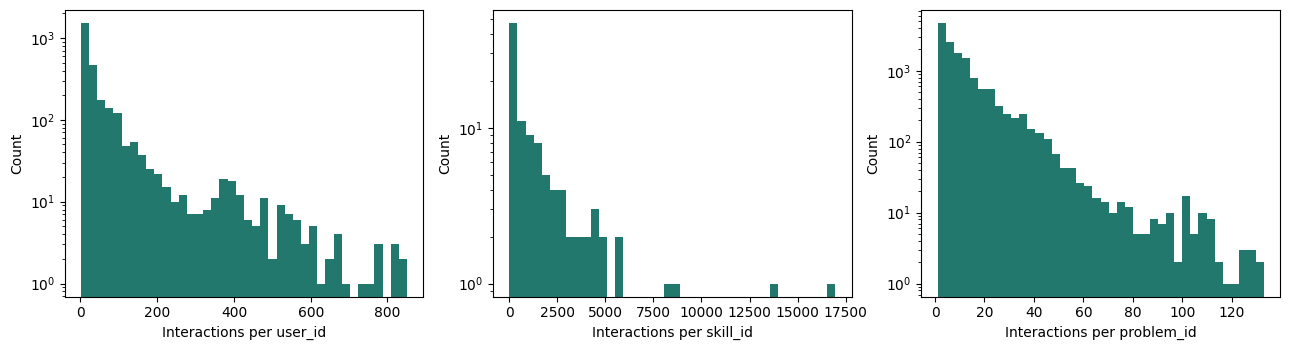

In [5]:
display(train.correct.value_counts(dropna=False).rename('count').to_frame())
print('Train success rate:',train.correct.mean())
counts = {entity:train.groupby(entity).size() for entity in ['user_id','skill_id','problem_id']}
summary = pd.DataFrame({k:v.describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]) for k,v in counts.items()})
display(summary)
summary.to_csv(TABLES / 'eda_train_support_summary.csv')
for key, values in counts.items():
    # Student IDs remain in private data directory.
    out = ROOT/'data/processed' if key=='user_id' else TABLES
    values.rename('interactions').to_csv(out / f'train_support_{key}.csv')
warmup = pd.DataFrame([{'warmup':w,'students_without_scored_rows':int((counts['user_id']<=w).sum()),
                       'scored_rows':int((counts['user_id']-w).clip(lower=0).sum())} for w in [3,5,10]])
display(warmup)
warmup.to_csv(TABLES/'eda_train_warmup.csv',index=False)
fig, axes = plt.subplots(1,3,figsize=(13,3.6))
for ax,(name,values) in zip(axes, counts.items()):
    ax.hist(values, bins=40, color='#23786e')
    ax.set(xlabel=f'Interactions per {name}', ylabel='Count', yscale='log')
fig.tight_layout()
fig.savefig(PLOTS/'eda_train_support.png',dpi=160)
plt.show()

## 4. Nhất quán skill/name và trajectory — TRAIN only

In [6]:
mapping = train.groupby('skill_id').agg(names=('skill_name','nunique'), interactions=('correct','size'))
display(mapping.sort_values('names',ascending=False).head(15))
name_mapping = train.groupby('skill_name').skill_id.nunique().sort_values(ascending=False)
print('Skill IDs with >1 nonmissing name:',int((mapping.names>1).sum()))
print('Names mapping to >1 skill ID:',int((name_mapping>1).sum()))
print('Rows with missing skill_name:',int(train.skill_name.isna().sum()))
# Anonymous trajectories in notebook; actual student IDs are not displayed.
for i,user in enumerate(sorted(train.user_id.unique())[:3], start=1):
    trajectory = train.loc[train.user_id.eq(user), ['order_id','skill_id','correct']].head(12)
    print(f'Train student example {i}')
    display(trajectory.reset_index(drop=True))
mapping.to_csv(TABLES/'eda_train_skill_name_mapping.csv')

,names,interactions
skill_id,,
1,1,315
11,1,2658
13,1,1029
12,1,495
110,1,358
15,1,508
165,1,64
163,1,154
16,1,530


Skill IDs with >1 nonmissing name: 0
Names mapping to >1 skill ID: 1
Rows with missing skill_name: 6143
Train student example 1


,order_id,skill_id,correct
0,21617893,13,0
1,21617915,15,1
2,21617924,15,1
3,21617931,13,0
4,21617942,15,1
5,21617953,13,0
6,21617962,13,0


Train student example 2


,order_id,skill_id,correct
0,23944780,279,1
1,23944797,279,1
2,23944811,279,1
3,23944830,279,1
4,23944849,279,1
5,23944907,279,1
6,23944935,279,1
7,23944952,279,1
8,23944969,279,1
9,23944981,279,1


Train student example 3


,order_id,skill_id,correct
0,32240404,311,0
1,32240479,311,1
2,32240527,311,1
3,32240567,311,1
4,32240910,312,1
5,32241238,312,1


## 5. Báo cáo và trạng thái gate

In [7]:
report = f"""# EDA — kết quả khởi động

- Raw: {len(df):,} dòng, {len(df.columns)} cột; {df.user_id.nunique():,} sinh viên.
- Thiếu skill: {audit['missing_skill_rows']:,} dòng.
- Sau lọc missing skill: {audit['rows_after_missing_skill_filter']:,} dòng.
- Multi-skill: {audit['multi_skill_rows']:,} dòng, separator `_`.
- Single-skill: {len(clean):,} dòng ({len(clean)/len(df):.2%}).
- Duplicate semantic rows: {audit['duplicate_semantic_rows']}; duplicate student/order: {audit['duplicate_student_order_rows']}.
- Repeated student/problem rows: {audit['repeated_student_problem_rows']} (không tự động xóa).
- Single-skill subset: {clean.user_id.nunique():,} students, {clean.problem_id.nunique():,} problems, {clean.skill_id.nunique():,} skills.
- Split student counts: { {k:len(v) for k,v in parts.items()} }.
- Train: {len(train):,} dòng; {train.skill_id.nunique()} skills; success rate {train.correct.mean():.4f}.
- Train students ≤5 interactions: {int((counts['user_id']<=5).sum())}.
- Skill IDs với nhiều tên trong train: {int((mapping.names>1).sum())}.
- Raw SHA-256: `{manifest['sha256']}`.

## Quyết định và giới hạn

EDA chi tiết dùng train; chưa tính metric mô hình hoặc dùng nhãn test để tuning.
Raw gốc không thay đổi. File người dùng cung cấp phù hợp schema corrected collapsed; chưa xác nhận checksum với bản tải chính thức.
Split manifest lưu tại data/processed/student_split.json; các bước sau phải dùng lại.
Gate A chưa đạt: còn preprocessing/features, leakage tests, sequential evaluator và Configuration Lock A.
Chưa train model, chưa hoàn thành RQ1/RQ2.

## Bước tiếp theo

Implement preprocessing và kiểm thử lịch sử shifted/OOF theo student; chọn cấu hình A từ support train.
Kiểm tra BKT dependency và Local LLM runtime trước các thí nghiệm tương ứng.
"""
(ROOT/'reports/eda_summary.md').write_text(report,encoding='utf-8')
print(report)

# EDA — kết quả khởi động

- Raw: 346,860 dòng, 31 cột; 4,217 sinh viên.
- Thiếu skill: 63,755 dòng.
- Sau lọc missing skill: 283,105 dòng.
- Multi-skill: 47,037 dòng, separator `_`.
- Single-skill: 236,068 dòng (68.06%).
- Duplicate semantic rows: 0; duplicate student/order: 0.
- Repeated student/problem rows: 4779 (không tự động xóa).
- Single-skill subset: 4,003 students, 14,734 problems, 105 skills.
- Split student counts: {'train': 2802, 'validation': 600, 'test': 601}.
- Train: 168,431 dòng; 105 skills; success rate 0.6580.
- Train students ≤5 interactions: 492.
- Skill IDs với nhiều tên trong train: 0.
- Raw SHA-256: `162ef8d2d28bcbfea6591a282994062bd8d5eaa00636544292a0d268dca6e5da`.

## Quyết định và giới hạn

EDA chi tiết dùng train; chưa tính metric mô hình hoặc dùng nhãn test để tuning.
Raw gốc không thay đổi. File người dùng cung cấp phù hợp schema corrected collapsed; chưa xác nhận checksum với bản tải chính thức.
Split manifest lưu tại data/processed/student_split.json; c